# Retail Inventory & Operations Analytics
### SQL-Driven BI Dataset | Python EDA & Validation

This notebook performs exploratory data analysis (EDA) and validation on a
BI-ready dataset created in SQL.

The SQL layer acts as the **single source of truth**, where:
- Data cleaning
- KPI engineering
- Business logic and flags

were already applied.

Python is used **for analysis, validation, and insight generation**.

## 1. Environment Setup

This section imports the required Python libraries and prepares the analysis
environment. Only standard data analysis libraries are used to ensure
readability and reproducibility.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings for better readability
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## 2. Load BI-Ready Dataset

The dataset loaded below is the **final output of the SQL pipeline**
(`bi_retail_operations_final`).

All KPIs and business rules were defined in SQL.
This notebook consumes that curated dataset for analysis and validation.


In [3]:
from google.colab import files
uploaded = files.upload()

Saving bi_retail_operations_final.csv to bi_retail_operations_final.csv


In [4]:
# Load the final SQL-derived dataset
df = pd.read_csv("bi_retail_operations_final.csv")

# Preview first few rows
df.head()

,order_date,store_id,product_id,category,region,season,inventory_level,units_sold,units_ordered,demand_forecast,inventory_turnover,demand_supply_gap,estimated_revenue,estimated_margin,inventory_status,promotion_effectiveness
0,2022-01-01,S001,P0001,Groceries,North,Autumn,231,127,55,135.47,0.55,-95.53,3403.60,-367.03,Overstock,No Promotion
1,2022-01-01,S001,P0002,Toys,South,Autumn,204,150,66,144.04,0.74,-59.96,7561.20,-2362.80,Overstock,No Promotion
2,2022-01-01,S001,P0003,Toys,West,Summer,102,65,51,74.02,0.64,-27.98,1637.41,-398.38,Healthy Stock,Low Promotion Impact
3,2022-01-01,S001,P0004,Toys,North,Autumn,469,61,164,62.18,0.13,-406.82,1796.33,-322.81,Overstock,Low Promotion Impact
4,2022-01-01,S001,P0005,Electronics,East,Summer,166,14,135,9.26,0.08,-156.74,1030.96,65.66,Healthy Stock,No Promotion


## 3. Data Validation & Sanity Checks

Before analysis, basic validation checks are performed to ensure:
- Correct data types
- No unexpected null values
- Reasonable metric distributions

This step helps build trust in the dataset.

In [5]:
# Dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_date               400 non-null    object 
 1   store_id                 400 non-null    object 
 2   product_id               400 non-null    object 
 3   category                 400 non-null    object 
 4   region                   400 non-null    object 
 5   season                   400 non-null    object 
 6   inventory_level          400 non-null    int64  
 7   units_sold               400 non-null    int64  
 8   units_ordered            400 non-null    int64  
 9   demand_forecast          400 non-null    float64
 10  inventory_turnover       400 non-null    float64
 11  demand_supply_gap        400 non-null    float64
 12  estimated_revenue        400 non-null    float64
 13  estimated_margin         400 non-null    float64
 14  inventory_status         4

In [6]:
# Summary statistics for numeric KPIs
df.describe()

,inventory_level,units_sold,units_ordered,demand_forecast,inventory_turnover,demand_supply_gap,estimated_revenue,estimated_margin
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,276.33,139.16,110.90,144.34,0.50,-131.99,7064.57,-852.15
std,127.79,108.99,53.42,109.59,0.29,106.32,6998.04,1384.25
min,51.00,0.00,20.00,-3.91,0.00,-458.87,0.00,-7411.14
25%,174.50,53.50,65.00,52.64,0.23,-190.84,2188.05,-1097.90
50%,268.00,108.50,115.00,115.13,0.51,-106.99,4626.02,-387.03
75%,397.25,206.00,157.00,215.06,0.75,-46.44,9942.23,-36.31
max,499.00,479.00,199.00,469.74,1.00,14.54,37893.69,1483.25


## 4. Inventory Risk Analysis

This section analyzes inventory health across products and stores using
the inventory status flags generated in SQL.

The goal is to understand how much inventory is at risk due to
low stock or overstock conditions.

In [7]:
# Distribution of inventory status
inventory_distribution = (
    df["inventory_status"]
    .value_counts(normalize=True)
    * 100
)

inventory_distribution

,proportion
inventory_status,
Overstock,66.00
Healthy Stock,34.00


## 5. Demand vs Supply Gap Analysis

The demand-supply gap indicates potential:
- Stockout risk (positive gap)
- Overstock risk (negative gap)

This analysis helps identify categories where demand consistently
outpaces inventory.

In [8]:
# Average demand-supply gap by category
df.groupby("category")["demand_supply_gap"].mean().sort_values(ascending=False)

,demand_supply_gap
category,
Clothing,-117.59
Toys,-130.11
Electronics,-131.83
Furniture,-135.47
Groceries,-144.30


## 6. Profitability Analysis

This section evaluates estimated revenue and margin by product category
to identify key profit drivers and low-margin areas.

All revenue and margin calculations originate from the SQL layer.

In [9]:
# Total estimated margin by category
df.groupby("category")["estimated_margin"].sum().sort_values(ascending=False)

,estimated_margin
category,
Furniture,-48251.96
Groceries,-51318.38
Electronics,-79329.51
Clothing,-79874.83
Toys,-82086.94


### Note on Estimated Margin Interpretation

The estimated margin values are negative across all categories.
This outcome is expected given the cost estimation approach used in this analysis.

Cost was approximated using competitor pricing due to the absence of actual
cost-of-goods-sold (COGS) data. Since competitor prices are typically higher
than internal unit costs, this method likely overestimates costs and results
in conservative (negative) margin estimates.

Therefore, margin values in this project should be interpreted as
**relative indicators** for comparison across categories, rather than
absolute profitability measures.

This approach is used for analytical demonstration and decision-support
purposes, not financial reporting.

## 7. Promotion Effectiveness Validation

This analysis validates whether promotional activities are associated
with higher unit sales compared to non-promotional periods.

In [10]:
# Average units sold by promotion effectiveness category
df.groupby("promotion_effectiveness")["units_sold"].mean()

,units_sold
promotion_effectiveness,
High Promotion Impact,129.34
Low Promotion Impact,131.12
No Promotion,147.60


### Promotion Effectiveness Analysis

This analysis compares average units sold across promotion effectiveness groups.

Interestingly, products with no promotion show higher average units sold than
promoted products. This suggests that promotions are often applied to products
with lower baseline demand, while high-demand products may perform well without
discounts.

Promotion effectiveness in this project measures performance relative to
forecasted demand rather than absolute sales volume. Therefore, results should
be interpreted as **incremental impact indicators**, not total sales drivers.

## 8. Visual Exploration

Simple visualizations are used to support analytical insights.
These plots are exploratory and not intended to replace BI dashboards.

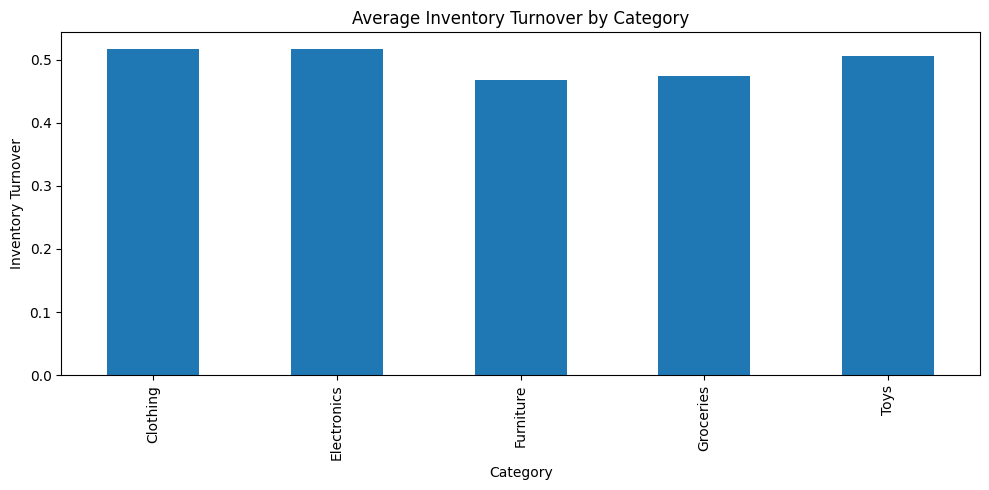

In [11]:
plt.figure(figsize=(10, 5))
df.groupby("category")["inventory_turnover"].mean().plot(kind="bar")
plt.title("Average Inventory Turnover by Category")
plt.xlabel("Category")
plt.ylabel("Inventory Turnover")
plt.tight_layout()
plt.show()

### Average Inventory Turnover by Category

This visualization compares the average inventory turnover ratio across
product categories.

Inventory turnover measures how efficiently inventory is converted into sales.
Higher values indicate faster-moving stock, while lower values suggest longer
inventory holding periods.

The results show moderate variation across categories, highlighting differences
in demand patterns and inventory management strategies.

## Conclusion & Key Insights

This analysis demonstrates how a SQL-driven BI dataset can be effectively
consumed in Python for validation, exploratory analysis, and insight generation
without duplicating business logic.

The SQL layer served as the single source of truth, where data cleaning,
KPI engineering, and business rules were applied. Python was then used to
analyze inventory efficiency, demand alignment, promotion effectiveness,
and relative profitability patterns.

### Key Insights

**1. Inventory efficiency varies moderately across categories**  
Average inventory turnover shows small but meaningful differences between
product categories. Electronics, Clothing, and Toys exhibit slightly higher
turnover rates, indicating faster-moving inventory, while Furniture and
Groceries tend to hold stock longer. This suggests that inventory
replenishment strategies should be tailored by category rather than applied
uniformly.

**2. Demand–supply gaps highlight operational risk areas**  
Positive demand–supply gaps indicate potential stockout risk in certain
categories and stores, while negative gaps point to overstock conditions.
These signals can be used to prioritize inventory rebalancing and improve
alignment between demand forecasts and ordering decisions.

**3. Promotion impact should be interpreted relative to expectations**  
Products classified as having high promotion impact outperformed their demand
forecasts, but they did not necessarily achieve the highest absolute sales
volumes. Non-promoted products showed higher average units sold, suggesting
that promotions are often targeted at lower-demand products rather than top
sellers. This highlights the importance of evaluating promotions based on
incremental performance rather than total volume alone.

**4. Estimated margins are conservative and comparative in nature**  
Estimated margin values are negative across categories due to the use of
competitor pricing as a proxy for cost. As a result, margin metrics should be
interpreted as relative indicators for comparison across categories, not as
actual profitability figures. Despite this limitation, the analysis still
supports identifying categories with comparatively stronger or weaker
performance.

### Overall Takeaway

This project illustrates how operational and inventory data can be transformed
into decision-support insights through structured SQL modeling and disciplined
Python analysis. By maintaining a clear separation between data preparation and
analysis, the workflow ensures consistency, transparency, and scalability.

The approach closely reflects real-world BI and analytics practices and
demonstrates how data analysts can support inventory optimization and
operational decision-making without relying on complex predictive models.